## Introduction

In this first laboratory we will see a few ways to exploit and adapt pre-trained models to solve new problems. We will start first by downloading and instantiating a new dataset and establishing a stable and reproducible baseline model based on a pre-trained CNN.

---

## Exercise 1 (Warmup): Exploratory Data Analysis and a Stable Baseline

For this laboratory we will work with [The German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/) [1]. We will begin, not with *detection*, but with a simpler traffic sign *classification* problem. This has two advantages: (1) the images are *smaller* than in the detection benchmark; and (2) a wrapper for the GTSRB dataset is conveniently included in the `torchvision` library.  

[1] Houben S, Stallkamp J, Salmen J, Schlipsing M, Igel C. Detection of traffic signs in real-world images: The German Traffic Sign Detection Benchmark. In The 2013 International Joint Conference on Neural Networks (IJCNN), 2013.

### Exercise 1.1: Exploratory Data Analysis

A good best practice to adopt in all experimental deep learning projects is thorough *exploratory data analysis*. In this exercise you should instantiate the GTSRB Dataset, inspect some images, and do some statistical analysis of the distribution of data (and metadata). A goal here is to keep an eye out for anything that might be problematic in what is to come.



In [1]:
## let's import the libraries needed
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import random
import os
import torchvision.transforms.v2 as T
from torchvision.datasets import GTSRB
from typing import Tuple, List, Optional, Any

### Let's define a function for reproducibility 

def set_determinism(seed):
    # 1. Python built-in random module
    random.seed(seed)
    
    # 2. Python hashing environment variable
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 1234
set_determinism(seed)

## setting the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("you are working on",device)


you are working on cuda


Since I carry out this EDA entirely in this notebook I 'll define all the function needed.

- First we define the functions needed to preprocess the data

In [2]:
def load_gtsrb_dataset(
    data_dir: str, 
    split: str = 'train', 
    transform: Optional[T.Compose] = None, 
    download: bool = True
    ):
    
    if transform is None:
        transform = T.Compose([
            T.ToImage(),
            T.ToDtype(torch.float32, scale=True)
        ])
        
    return GTSRB(
        root=data_dir, 
        split=split, 
        transform=transform, 
        download=download
    )

def get_standard_transforms(
    resize_dim: int = 70, 
    crop_dim: Tuple[int, int] = (64, 64),
    mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
    std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
    flip: bool = True,
    test : bool = False
):

    transform = [
        T.Resize(resize_dim),
    ]

    if test :
        transform.append(T.CenterCrop(crop_dim))
    else :
        transform.append(T.RandomCrop(crop_dim))
        if flip:
            transform.append(T.RandomHorizontalFlip())

    transform += [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=mean, std=std)
    ]

    print(transform)
    return T.Compose(transform)


In [3]:
try:
    transform = get_standard_transforms(resize_dim=70, crop_dim=(64, 64))
    print("get_standard_transforms() executed successfully.")
    train_ds = load_gtsrb_dataset(data_dir='_data/', split='train', transform=transform, download=True)
    img, label = train_ds[0]
    print(f"load_gtsrb_dataset() executed successfully.")
    print(f"Sample image shape: {img.shape} (Expected: torch.Size([3, 64, 64]))")
    print(f"Image tensor dtype: {img.dtype} (Expected float32)") 
    print(f"Sample label type: {type(label)} (Expected: int)")
except Exception as e:
    print(f"Testing failed with error: {e}")

[Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True), RandomCrop(size=(64, 64), pad_if_needed=False, fill=0, padding_mode=constant), RandomHorizontalFlip(p=0.5), ToImage(), ToDtype(scale=True), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)]
get_standard_transforms() executed successfully.
load_gtsrb_dataset() executed successfully.
Sample image shape: torch.Size([3, 64, 64]) (Expected: torch.Size([3, 64, 64]))
Image tensor dtype: torch.float32 (Expected float32)
Sample label type: <class 'int'> (Expected: int)


Now let's **visualize some images**.

In [4]:
mean_tensor = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_tensor = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def plot_sample_grid(
    dataset,
    indices,
    num_samples: int = 100, 
    grid_shape: Tuple[int, int] = (10, 10), 
    figsize: Tuple[int, int] = (15, 20),
    title: str = "Dataset Samples",
    denormalize : bool = True,
    ):

    if indices is None:
        indices = np.random.choice(range(len(dataset)), num_samples, replace=False)    ## generates indices for taking some casual images
    fig, axes = plt.subplots(grid_shape[0], grid_shape[1], figsize=figsize)        ## basically creating the thumbnail for the images
    axes = axes.flatten() ## for iterating more easily on them
    
    fig.suptitle(title, fontsize=16, y=0.92)
    
    for i, idx in enumerate(indices):
        img, cls = dataset[idx]
        
        if isinstance(img, torch.Tensor):
            print("Image passed as a tensor")
            if denormalize:
                print("denomalizing...")
                img = torch.clamp((img.detach().cpu() * std_tensor) + mean_tensor, 0.0, 1.0).permute([1, 2, 0]).numpy()   ## matplot lib can visualize the image between [0,1] completely fine
            else:
                img = torch.clamp(img.detach().cpu() , 0.0, 1.0).permute([1, 2, 0]).numpy()  


        axes[i].imshow(img)
        axes[i].set_title(f'CLS: {cls}', fontsize=8)
        axes[i].axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.show()

Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor


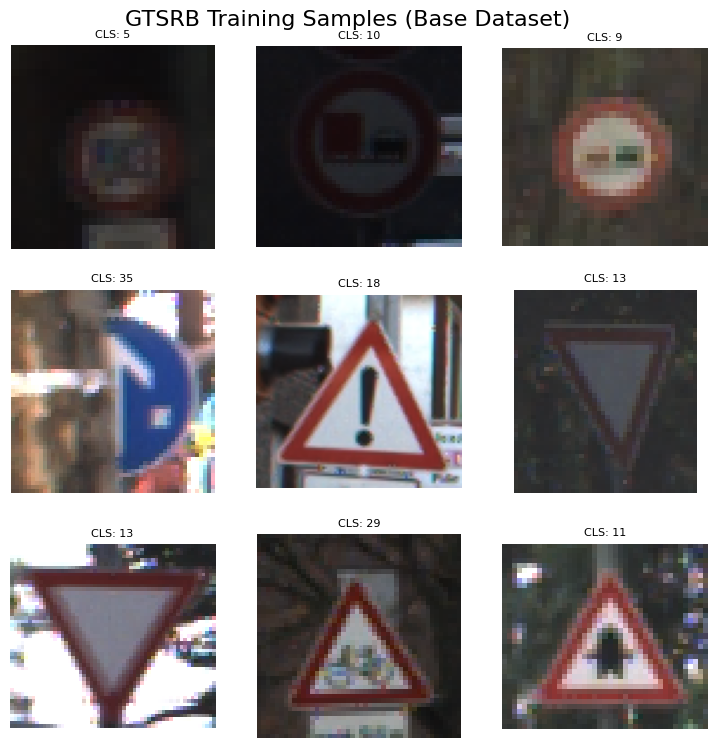

Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor
Image passed as a tensor


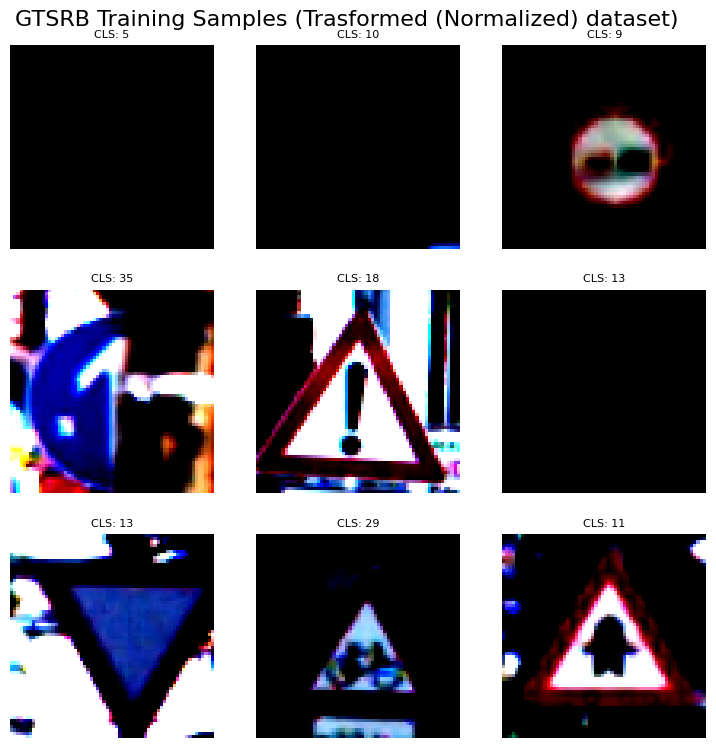

Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...
Image passed as a tensor
denomalizing...


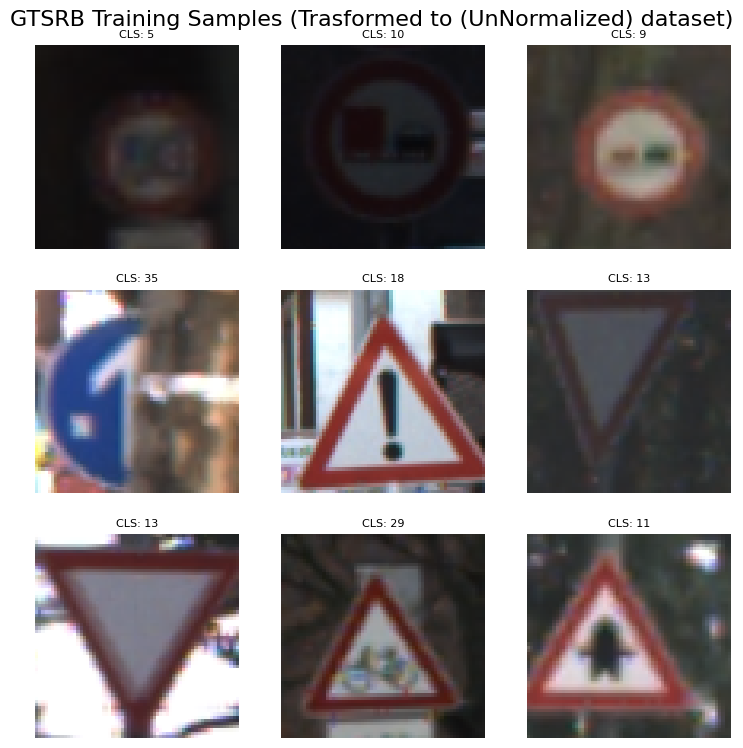

In [5]:
train_ds_original = load_gtsrb_dataset(data_dir='_data/', split='train',download=True)
num_sample = 9
indices = np.random.choice(range(len(train_ds_original)), num_sample, replace=False)

grid_shape = (3,3)
fig_size = (9,9)
plot_sample_grid(
    dataset=train_ds_original, 
    indices= indices,
    num_samples=num_sample, 
    grid_shape=grid_shape, 
    figsize=fig_size, 
    title="GTSRB Training Samples (Base Dataset)",
    denormalize=False
)
plot_sample_grid(
    dataset=train_ds, 
    indices= indices,
    num_samples=num_sample, 
    grid_shape= grid_shape, 
    figsize= fig_size, 
    title="GTSRB Training Samples (Trasformed (Normalized) dataset)",
    denormalize= False
)
plot_sample_grid(
    dataset=train_ds,
    indices= indices, 
    num_samples=num_sample, 
    grid_shape= grid_shape, 
    figsize=fig_size, 
    title="GTSRB Training Samples (Trasformed to (UnNormalized) dataset)",
    denormalize=True
)

As we can see our pipeline , as well as denormalization , works.

Now let's define a function that gets the **metadata** of original dataset

In [6]:
def extract_dataset_metadata(dataset: GTSRB) -> pd.DataFrame:
    records = []
    
    for idx in range(len(dataset)):
        img, cls = dataset[idx]
        
        if isinstance(img, torch.Tensor):
            height, width = img.shape[1], img.shape[2]
        else:
            width, height = img.size
            
        aspect_ratio = width / height
        records.append((cls, height, width, aspect_ratio))
        
    return pd.DataFrame(records, columns=['CLS', 'HEIGHT', 'WIDTH', 'AR'])

In [8]:
print("Extracting dataset spatial metadata... This may take a few moments.")
df_metadata = extract_dataset_metadata(train_ds_original)

Extracting dataset spatial metadata... This may take a few moments.


In [9]:
df_metadata[["HEIGHT", "WIDTH", "AR"]].describe()

,HEIGHT,WIDTH,AR
count,26640.000000,26640.000000,26640.000000
mean,50.365128,50.933784,1.008718
std,23.161523,24.373418,0.072100
min,25.000000,25.000000,0.368132
25%,35.000000,35.000000,0.972222
50%,43.000000,43.000000,1.000000
75%,58.000000,58.000000,1.044444
max,225.000000,243.000000,1.417808


Let's visualize the **histogram about height,width and AR**.

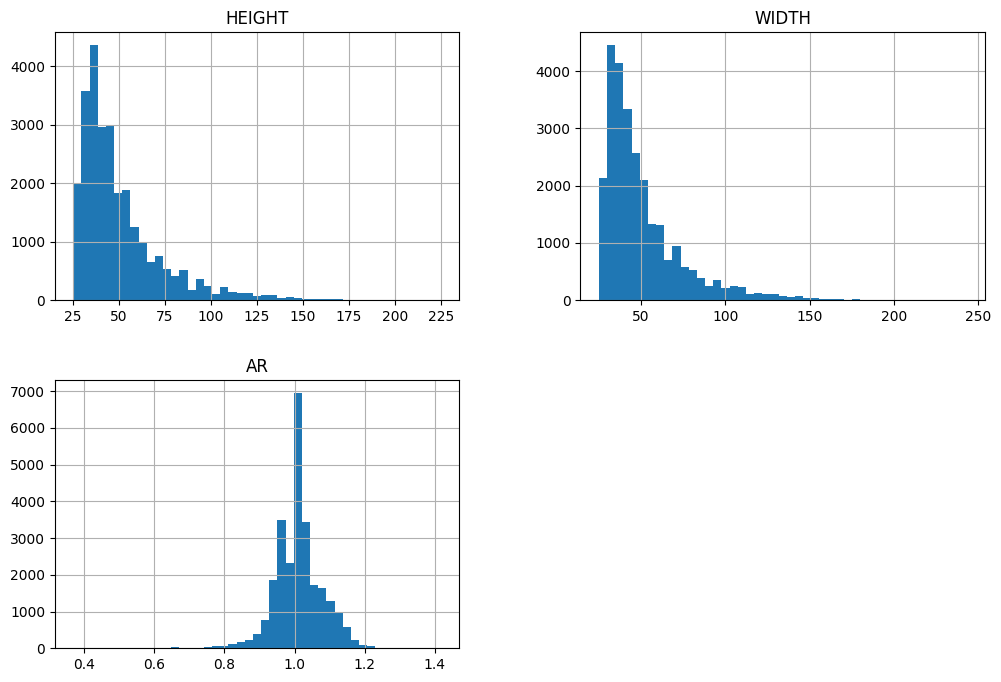

In [12]:
_ = df_metadata[["HEIGHT", "WIDTH", "AR"]].hist(bins=45, figsize=(12, 8))

As shown, most images are square because the aspect‑ratio 'distribution' is **strongly peaked at 1**.

CLS colomn (classe histogram) require a more fine-grained observation maybe we can take the proportion of the class and weight the observation.

In [17]:
print("\n Class Distribution Counts (Top 10 Most Frequent) : ")
print(df_metadata['CLS'].value_counts().head(10))

print("\n Class Distribution Counts (Top 10 Least Frequent) : ")
print(df_metadata['CLS'].value_counts().tail(10))


 Class Distribution Counts (Top 10 Most Frequent) : 
CLS
1     1500
2     1500
13    1440
12    1410
38    1380
10    1350
4     1320
5     1260
25    1020
9      990
Name: count, dtype: int64

 Class Distribution Counts (Top 10 Least Frequent) : 
CLS
39    210
24    180
27    180
29    180
32    180
41    180
42    180
0     150
19    150
37    150
Name: count, dtype: int64


So the least represented classes are **37, 19, and 0,** each appearing just 150 times.

To better visualize it we can plot the  **class count histogram**.

<Axes: xlabel='CLS'>

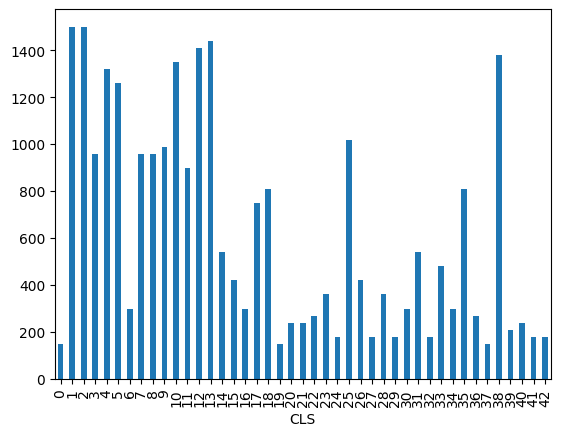

In [19]:
df_metadata['CLS'].value_counts().sort_index().plot(kind='bar')

Let's define a function to get the associated class weights (we return a tensor so it could be later used...maybe).  
Weights are inversely proportioned to the frequencies.

In [20]:
def get_class_weights(class_counts):
    counts = torch.tensor(class_counts, dtype=torch.float32)
    weights = 1.0 / counts
    weights = weights / weights.sum()
    return weights

Finally here we get the class weights as mentioned before

In [ ]:
class_counts = df_metadata['CLS'].value_counts().sort_index()
weights = get_class_weights(class_counts)
assert class_counts.argmin() == weights.argmax()     ## I expect the less present class having an higher weight
print(weights)

tensor([0.0541, 0.0054, 0.0054, 0.0085, 0.0061, 0.0064, 0.0271, 0.0085, 0.0085,
        0.0082, 0.0060, 0.0090, 0.0058, 0.0056, 0.0150, 0.0193, 0.0271, 0.0108,
        0.0100, 0.0541, 0.0338, 0.0338, 0.0301, 0.0225, 0.0451, 0.0080, 0.0193,
        0.0451, 0.0225, 0.0451, 0.0271, 0.0150, 0.0451, 0.0169, 0.0271, 0.0100,
        0.0301, 0.0541, 0.0059, 0.0386, 0.0338, 0.0451, 0.0451])



---
### Exercise 1.2: A Stable and Reproducible Baseline

In this exercise you should implement code to use a pretrained network as a *feature extractor* that, instead of *classifying* images in input, should return the *feature representation* from the last layer of the pretrained model before the classifier. These features, extracted from the train set, should be used to train a *classical* model for classification (e.g. an SVM, a Nearest Neighbor, or a Linear Discriminant classifier from Scikit-learn). Evaluate the performance of this baseline model on the features extracted from the test set.

In [6]:
from torchvision.models import list_models, get_model
print("Available models are the following : \n",list_models())

Available models are the following : 
 ['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'fasterrcnn_mobilenet_v3_large_320_fpn', 'fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn', 'fasterrcnn_resnet50_fpn_v2', 'fcn_resnet101', 'fcn_resnet50', 'fcos_resnet50_fpn', 'googlenet', 'inception_v3', 'keypointrcnn_resnet50_fpn', 'lraspp_mobilenet_v3_large', 'maskrcnn_resnet50_fpn', 'maskrcnn_resnet50_fpn_v2', 'maxvit_t', 'mc3_18', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'mvit_v1_b', 'mvit_v2_s', 'quantized_googlenet', 'quantized

For this notebook let's choose **resnet18**.

In [7]:
from torch.utils.data import DataLoader
import torch.nn as nn

## we reload the dataset and include also test data
train_transform = get_standard_transforms(resize_dim=70, crop_dim=(64, 64),test=False)
train_ds = load_gtsrb_dataset(data_dir='_data/', split='train', transform=train_transform,download=True)

test_transform = get_standard_transforms(resize_dim=70, crop_dim=(64, 64),test=True)
test_ds = load_gtsrb_dataset(data_dir='_data/', split='test', transform=test_transform, download=True)


batch_size = 1024
dl_train = DataLoader(train_ds, batch_size=batch_size, shuffle=  True)
dl_test = DataLoader(test_ds, batch_size=batch_size,shuffle = False)
print("\nOur dataset consists of",len(dl_train.dataset),"points for training and",len(dl_test.dataset),"for testing")


[Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True), RandomCrop(size=(64, 64), pad_if_needed=False, fill=0, padding_mode=constant), RandomHorizontalFlip(p=0.5), ToImage(), ToDtype(scale=True), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)]
[Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True), CenterCrop(size=(64, 64)), ToImage(), ToDtype(scale=True), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)]

Our dataset consists of 26640 points for training and 12630 for testing


Now we **load our model** and visualize it.

In [8]:
model = get_model('resnet18', weights='DEFAULT')
print("Model architecture :\n",model)

Model architecture :
 ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu):

From the architecture we can see that `avgpool` transforms the tensor  
**B × C × H × W → B × C × 1 × 1**, collapsing the spatial dimensions.  
By removing the classification head (`fc`), we can use the network as a **feature extractor**,  
where the final feature vector has shape **B × C** after flattening.


In [10]:
model.fc = nn.Identity()
model = model.to(device)

Now we write a single function that extracts the **features we need**, and later apply it to both the **train and test loaders** so we can eventually **classify using those features**.

In [11]:
from tqdm.notebook import tqdm

def get_features(model,dataloader):
    feats = []
    classes = []
    model.eval()
    for (ims, cls) in tqdm(dataloader):
        ims = ims.to(device)
        with torch.no_grad():
            feats.append(model(ims))
        classes.append(cls)
    feats = torch.vstack(feats).cpu()
    print(feats)
    classes = torch.concat(classes)
    print(classes)
    return feats,classes

I **collect the features from both dataloaders** and check if the shapes matches.

In [19]:
print("tqdm shoud have",(len(dl_train.dataset) // dl_train.batch_size)+1,"step")
train_features , train_classes = get_features(model,dl_train)
train_features.shape

tqdm shoud have 27 step


  0%|          | 0/27 [00:00<?, ?it/s]

tensor([[0.3995, 6.2182, 1.8803,  ..., 0.6393, 0.0067, 0.9655],
        [0.0000, 1.6445, 0.2623,  ..., 0.3079, 0.0000, 0.5393],
        [0.0000, 0.2464, 3.6772,  ..., 0.4743, 0.0000, 0.0000],
        ...,
        [0.0942, 0.0000, 1.8826,  ..., 2.2317, 1.6326, 0.0204],
        [2.1845, 3.8344, 1.6233,  ..., 2.0484, 0.9953, 0.1131],
        [1.7476, 0.0000, 0.0333,  ..., 0.7255, 1.5676, 1.4994]])
tensor([13, 15, 36,  ...,  3, 13,  8])


torch.Size([26640, 512])

In [ ]:
print("tqdm shoud have",(len(dl_test.dataset) // dl_test.batch_size)+1,"step")
test_features, test_classes = get_features(model,dl_test)
test_features.shape

tqdm shoud have 13 step


  0%|          | 0/13 [00:00<?, ?it/s]

tensor([[0.0000, 0.0000, 0.0000,  ..., 1.6609, 0.1014, 0.0000],
        [0.0000, 0.0506, 1.7206,  ..., 2.6801, 0.0000, 0.0000],
        [1.4155, 0.1309, 2.3257,  ..., 1.9778, 0.0000, 0.0000],
        ...,
        [4.6304, 0.0000, 0.0000,  ..., 2.6709, 2.3245, 0.0000],
        [0.0000, 0.0000, 0.2889,  ..., 3.9427, 1.3716, 2.0518],
        [3.2414, 0.0150, 0.0000,  ..., 3.3925, 0.0000, 0.0813]])
tensor([16,  1, 38,  ...,  6,  7, 10])


torch.Size([12630, 512])

### Classification

Now let's use a **svm to classify** from scikit-learn.
#### How SVMs work

A Support Vector Machine finds the **hyperplane that best separates two classes**, by maximizing the margin — the distance between the hyperplane and the closest points of each class. Those closest points are the **support vectors**: only they determine the decision boundary, everything else is irrelevant.

When classes aren't linearly separable, SVM uses a **kernel function** to implicitly project the data into a higher-dimensional space where a linear separator does exist, without ever computing that projection explicitly (the "kernel trick"). With  **kernel=linear**, no projection happens — it just looks for a straight-line (or hyperplane) boundary in the original feature space, which works well when classes are already roughly linearly separable.


In [54]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report

def svm_classify(train_features,train_classes,test_features,test_classes,kernel : str):
    svc = SVC(kernel=kernel)
    fitted_svc = svc.fit(train_features, train_classes)
    return fitted_svc,classification_report(test_classes, svc.predict(test_features))
    

Let's classify using three different kernels - **linear first**

In [ ]:
_ , linear_report = svm_classify(train_classes=train_classes,train_features=train_features,test_classes=test_classes,
                   test_features=test_features,kernel='linear')
print(linear_report)

              precision    recall  f1-score   support

           0       0.28      0.32      0.30        60
           1       0.53      0.68      0.59       720
           2       0.46      0.50      0.48       750
           3       0.33      0.35      0.34       450
           4       0.61      0.54      0.57       660
           5       0.53      0.47      0.49       630
           6       0.93      0.86      0.90       150
           7       0.54      0.56      0.55       450
           8       0.48      0.38      0.43       450
           9       0.88      0.76      0.82       480
          10       0.82      0.89      0.85       660
          11       0.50      0.63      0.56       420
          12       0.94      0.98      0.96       690
          13       0.96      0.99      0.97       720
          14       0.90      0.83      0.87       270
          15       0.99      0.97      0.98       210
          16       0.90      0.75      0.81       150
          17       0.97    

Now with **rbf kernel**   $K(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$ :

In [ ]:
_ , rbf_report = svm_classify(train_classes=train_classes,train_features=train_features,test_classes=test_classes,
                   test_features=test_features,kernel='rbf')
print(rbf_report)

              precision    recall  f1-score   support

           0       0.19      0.10      0.13        60
           1       0.56      0.68      0.62       720
           2       0.47      0.49      0.48       750
           3       0.33      0.35      0.34       450
           4       0.62      0.55      0.58       660
           5       0.56      0.55      0.56       630
           6       0.97      0.86      0.91       150
           7       0.57      0.54      0.55       450
           8       0.42      0.33      0.37       450
           9       0.88      0.76      0.82       480
          10       0.78      0.94      0.85       660
          11       0.47      0.54      0.50       420
          12       0.92      0.99      0.95       690
          13       0.96      0.99      0.97       720
          14       0.94      0.80      0.86       270
          15       0.99      0.91      0.95       210
          16       0.91      0.70      0.79       150
          17       0.95    

Finally **polinomial kernel** :

In [ ]:
_ , poly_report = svm_classify(train_classes=train_classes,train_features=train_features,test_classes=test_classes,
                   test_features=test_features,kernel='poly')
print(poly_report)

              precision    recall  f1-score   support

           0       0.20      0.12      0.15        60
           1       0.56      0.68      0.62       720
           2       0.50      0.47      0.48       750
           3       0.35      0.37      0.36       450
           4       0.62      0.57      0.59       660
           5       0.59      0.58      0.58       630
           6       0.96      0.79      0.87       150
           7       0.57      0.59      0.58       450
           8       0.45      0.39      0.42       450
           9       0.88      0.70      0.78       480
          10       0.79      0.93      0.85       660
          11       0.53      0.52      0.53       420
          12       0.88      0.97      0.92       690
          13       0.89      0.96      0.92       720
          14       0.92      0.81      0.86       270
          15       0.95      0.98      0.96       210
          16       0.90      0.67      0.77       150
          17       0.98    

Considering the weighted avg **f1-score**  =  $2 \cdot \frac{precison \cdot recall}{precision + recall}$  
we can report the follwing 3 number for each kernel:

- **linear  0.63**
- **rbf     0.62**
- **poly    0.62**

And as expected these procedures **fail badly to classify point belonging to the least frequent classes**.


---
### Exercise 1.3: A Fine-tuning Baseline

In this exercise you should try to *improve* on the stable baseline given by the feature extraction + SVM (or whatever) classifier you produced in the previous lecture. To do this, you should *fine-tune* the ResNet-18 (or whatever model you chose) to solve the new classification task.

To do this, you could proceed by:
1. Loading the ResNet-18 (or whatever) model and replacing the final FC layer (the classifier) with a *new* classifier. This could be a single Linear layer, or could be an MLP.
2. Training the resulting model on the GTSRB dataset for a few epochs.
3. Evaluating the resulting performance.

Some things you should probably consider (especially thinking about the *next* exercise):
+ You should be monitoring not only the loss on the training set, but also a *validation* loss on an *independent* validation set. Split the training set into two datasets: one with, say, 80% of the original training samples, and another with the remaining 20%. You can use this smaller set to monitor performance and check for *overfitting*.
+ Maybe the best strategy is to not fine-tune *all* layers, but only the last few. Think about *selectively* fine-tuning layers of the network.
+ Maybe a *single* linear layer isn't the best option for the classifier. Think about using an MLP instead.

Let's define **hyperparameter configuration**.

In [9]:
CONFIG = {
    "lr": 1e-3,
    "batch_size": 64,
    "epochs": 40,
    "num_classes": 43,  # GTSRB has 43 clases
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "num_workers" : min(8, os.cpu_count() // 2) 
}
print(f"Using device: {CONFIG['device']}")

Using device: cuda


We define a wrapper class that performs the train/validation split using sklearn’s `train_test_split`, which **allows stratification** and the **use of different transforms** for each subset , something not directly supported by the default dataset interface.  

In [10]:
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
import torch

class MLDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)
    

full_ds = load_gtsrb_dataset(data_dir='_data/', split='train', transform=None, download=True)

train_indices, val_indices = train_test_split(
    np.arange(len(full_ds)),
    test_size=0.2,                  
    random_state = seed,         
)

train_subset = torch.utils.data.Subset(full_ds, train_indices)
val_subset = torch.utils.data.Subset(full_ds, val_indices)



train_transform = get_standard_transforms(resize_dim=70, crop_dim=(64, 64),test=False)
val_transform = get_standard_transforms(resize_dim=70, crop_dim=(64, 64),test=True)



train_dataset = MLDataset(train_subset, transform=train_transform)
val_dataset = MLDataset(val_subset, transform=test_transform)

print("Total point of training :",len(full_ds))
print("training split :",len(train_dataset)," validation split :",len(val_dataset))
assert len(full_ds) == len(train_dataset) + len(val_dataset) ,f"sum equal to {len(train_dataset) + len(val_dataset)}"

[Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True), RandomCrop(size=(64, 64), pad_if_needed=False, fill=0, padding_mode=constant), RandomHorizontalFlip(p=0.5), ToImage(), ToDtype(scale=True), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)]
[Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True), CenterCrop(size=(64, 64)), ToImage(), ToDtype(scale=True), Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)]
Total point of training : 26640
training split : 21312  validation split : 5328


Now we create the loaders using our custom (sub)datasets.

In [ ]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=CONFIG["batch_size"], 
    shuffle=True, 
    num_workers= CONFIG["num_workers"]
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=CONFIG["batch_size"], 
    shuffle=False, 
    num_workers=CONFIG["num_workers"]
)

### Quick test
def num_split(total,batch_size):
    if total % batch_size == 0 :
        return total // batch_size 
    else :
        return (total // batch_size ) + 1

assert num_split(len(train_dataset),CONFIG["batch_size"]) == len(train_loader)
assert num_split(len(val_dataset),CONFIG["batch_size"])   == len(val_loader)

## we do various print to assure the object are built correctly
print(len(train_loader.dataset.subset))
print(len(val_loader.dataset.subset))
## asserting if we splitted correctly
assert len(train_loader.dataset.subset) + len(val_loader.dataset.subset) == len(train_loader.dataset.subset.dataset)
print(train_loader.dataset.transform)
print(val_loader.dataset.transform)

21312
5328
Compose(
      Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True)
      RandomCrop(size=(64, 64), pad_if_needed=False, fill=0, padding_mode=constant)
      RandomHorizontalFlip(p=0.5)
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)
Compose(
      Resize(size=[70], interpolation=InterpolationMode.BILINEAR, antialias=True)
      CenterCrop(size=(64, 64))
      ToImage()
      ToDtype(scale=True)
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
)


Now we define two functions
  - one to freeze all the layers
  - one to activate a specific layer given the specific string name of the layer  

Our purpose is to activate the `fc` layer and deactivate the backbone.

In [12]:
def freeze_all_layers(model):
    for param in model.parameters():
        param.requires_grad = False

def activate_layer(model, layer: str):
    layer = getattr(model, layer)
    for param in layer.parameters():
        param.requires_grad = True

Next there is the definition of the function that **returns an mlp layer**. 

In [13]:
def get_mlp_block(ft_in = 512,hidden_dim = 256,drop_out = 0.5 ,num_classes = 43):
    return nn.Sequential(
            nn.Linear(ft_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Linear(hidden_dim, num_classes)
        )

Now we **load the resnet with its weights** , **freeze the backbone** and **make the MLP trainable**.

In [34]:
model = get_model('resnet18', weights='DEFAULT')
model.fc = get_mlp_block()
freeze_all_layers(model)
activate_layer(model,"fc")
model.to(CONFIG["device"])

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In the following cell there are the definitions of the training loop (for one epoch) and of the validation for one epoch.

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)            ## B x num_of_classes
        loss = criterion(outputs, labels)  ## shuold return a scalar
        loss.backward()
        optimizer.step()
        
        ## to handle non uniform batch(every batch has the same number of observartion)
        running_loss += loss.item() * images.size(0)
        pred = outputs.argmax(dim = -1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)
        
    return running_loss / total, correct / total

def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            pred = outputs.argmax(dim = -1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            
    return running_loss / total, correct / total 

**Main training loop** (with savings at last)

In [35]:
import torch.optim as optim
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=CONFIG["lr"])
criterion = nn.CrossEntropyLoss()

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []


epochs = CONFIG["epochs"]


for epoch in range(1,epochs+1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, CONFIG["device"])

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_loss, val_acc = validate_epoch(model, val_loader, criterion, CONFIG["device"])
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
   
    print('Train_Loss:',f'{train_loss:.4f}', 
        'Train_Acc:', f'{train_acc*100:.2f}%',
        'Val_Loss:', f'{val_loss:.4f}', 
        'Val_Acc:', f'{val_acc*100:.2f}%')

Train_Loss: 2.0967 Train_Acc: 39.66% Val_Loss: 1.3053 Val_Acc: 60.47%
Train_Loss: 1.4482 Train_Acc: 54.26% Val_Loss: 1.0397 Val_Acc: 67.74%
Train_Loss: 1.2963 Train_Acc: 58.61% Val_Loss: 0.9368 Val_Acc: 70.42%
Train_Loss: 1.2033 Train_Acc: 60.82% Val_Loss: 0.8357 Val_Acc: 73.40%
Train_Loss: 1.1506 Train_Acc: 62.28% Val_Loss: 0.7994 Val_Acc: 74.38%
Train_Loss: 1.0973 Train_Acc: 64.48% Val_Loss: 0.7408 Val_Acc: 75.41%
Train_Loss: 1.0522 Train_Acc: 65.64% Val_Loss: 0.7351 Val_Acc: 76.37%
Train_Loss: 1.0329 Train_Acc: 66.14% Val_Loss: 0.7096 Val_Acc: 76.48%
Train_Loss: 1.0182 Train_Acc: 66.51% Val_Loss: 0.6715 Val_Acc: 78.19%
Train_Loss: 0.9856 Train_Acc: 67.54% Val_Loss: 0.6464 Val_Acc: 79.67%
Train_Loss: 0.9770 Train_Acc: 67.96% Val_Loss: 0.6088 Val_Acc: 80.03%
Train_Loss: 0.9495 Train_Acc: 68.80% Val_Loss: 0.5956 Val_Acc: 80.91%
Train_Loss: 0.9536 Train_Acc: 68.71% Val_Loss: 0.5860 Val_Acc: 81.51%
Train_Loss: 0.9251 Train_Acc: 69.54% Val_Loss: 0.5639 Val_Acc: 81.76%
Train_Loss: 0.9160 T

Finally we visualize the **results of our training**

In [36]:
import matplotlib.pyplot as plt

def plot_training_history(train_losses, val_losses, train_accs, val_accs):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Losses

    ax1.plot(epochs, train_losses, label='Train Loss', marker='o', color='#1f77b4', linewidth=2)
    ax1.plot(epochs, val_losses, label='Validation Loss', marker='o', color='#ff7f0e', linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Accuracies
    train_accs_pct = [acc * 100 for acc in train_accs]
    val_accs_pct = [acc * 100 for acc in val_accs]
    
    ax2.plot(epochs, train_accs_pct, label='Train Accuracy', marker='o', color='#1f77b4', linewidth=2)
    ax2.plot(epochs, val_accs_pct, label='Validation Accuracy', marker='o', color='#ff7f0e', linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(loc='lower right')
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    plt.show()

Finally we plot the results

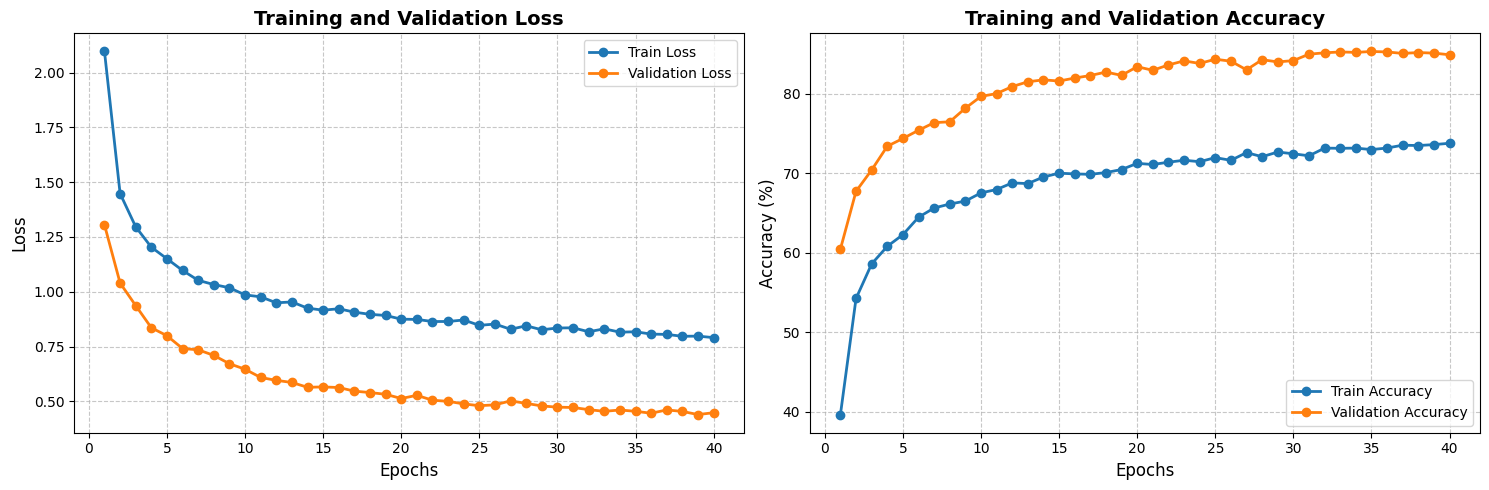

In [39]:
plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

We obtain a maximum **validation accuracy of 0.85** on 40 epochs 

Now we have to test our model. Since our `validate_epoch()` function doesn't return predictions and true labels we define a new function that is equal to the latter but also return what we need.

In [62]:
def test(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    t_preds = []
    t_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            pred = outputs.argmax(dim = -1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            t_preds.append(pred.cpu())
            t_labels.append(labels.cpu())
            
    return running_loss / total, correct / total , torch.cat(t_preds).numpy(), torch.cat(t_labels).numpy()

I ran **validate anyway** before calling the new function

In [65]:
print(validate_epoch(model,val_loader,criterion,CONFIG['device']))

(0.4479839105505843, 0.8490990990990991)


In [66]:
print(validate_epoch(model,dl_test,criterion,CONFIG['device']))

(1.7756468711914943, 0.5512272367379256)


Here I call the new function.

In [64]:
test_loss , test_acc , pred , true_labels = test(model,dl_test,criterion,CONFIG["device"])
print(test_acc)
print(classification_report(true_labels,pred))

0.5512272367379256
              precision    recall  f1-score   support

           0       0.34      0.25      0.29        60
           1       0.54      0.56      0.55       720
           2       0.42      0.56      0.48       750
           3       0.28      0.26      0.27       450
           4       0.52      0.53      0.52       660
           5       0.34      0.46      0.39       630
           6       0.73      0.77      0.75       150
           7       0.64      0.53      0.58       450
           8       0.40      0.21      0.27       450
           9       0.62      0.54      0.58       480
          10       0.68      0.81      0.74       660
          11       0.55      0.34      0.42       420
          12       0.85      0.89      0.87       690
          13       0.88      0.92      0.90       720
          14       0.94      0.79      0.86       270
          15       0.88      0.87      0.88       210
          16       0.96      0.77      0.85       150
        

This is **even worse than the basline**
Probabily 40 epochs was a little too much and the model **overfitted** the data but somehow even **while doing good on the validation set**.
Later in the next exercise I will lower the epochs and try try to unfreeze tha last 2 layer + the classifer as well as changing the optimezer to Adam with a much lower learning rate.

---
---
## Exercise 2: Pipeline Consolidation

Consolidate your implementation. When building applications based asd on Deep Learning, you will inevitably need to run many, many experiments. So, it is *always* a good idea to engineer a reproducible pipeline that allows you to run (and re-run) experiments with different hyperparameters. In this exercise you should do exactly this: engineer a deep learning pipeline that encapsulates (at least) training and evaluation so that you can easily and reproducibly run multiple experiments and compare the results.

Some things to think about when engineering this pipeline:
- **Model and Loss (and maybe Optimizer) Abstraction**: An important variable in training deep models is the model (obviously), the loss (somewhat less obvious), and the optimizer (less obvious) used during training. Your pipeline should probably be able to adapt to these changing configurations.
- **Configuration management**: Instead of global variables specializing each cell, thread a configuration object through your code (or use a singleton). If you are planning to use an IDE and not this notebook for the lab, you might consider using a configuration management library like [OmegaConf](https://omegaconf.readthedocs.io/en/2.3_branch/) which will help instrument your code so that you can pass configuration overrides via command line arguments.
- **Logging**: You will invariably need to run and compare multiple experiments. Instrument your code for monitoring training. Good options are [Tensorboard](https://docs.pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) or [Weights and Biases (WandB)](https://wandb.ai/site/). My PhD students seem to overwhelmingly prefer Weights and Biases. The configuration parameters should be used to facilitate distinguishing and comparing multiple runs with multiple hyperparameters.

---

To architect this pipeline, I developed several Python modules that resulted in the following structure. I tried to design it by taking inspiration from some aspects of Hugging Face’s `Trainer`.

### Folder structure

<pre style="font-family: monospace; font-size: 14px;">
<span style="color:blue">dl_pipeline/</span>
    ├── <span style="color:blue">configs/</span>
    │   ├── <span style="color:purple">config.yaml</span>
    │   ├── <span style="color:blue">logger/</span>
    │   │   └── <span style="color:purple">wandb.yaml</span>
    │   ├── <span style="color:blue">loss/</span>
    │   │   └── <span style="color:purple">cross_entropy.yaml</span>
    │   ├── <span style="color:blue">model/</span>
    │   │   └── <span style="color:purple">resnet18.yaml</span>
    │   └── <span style="color:blue">optimizer/</span>
    │       ├── <span style="color:purple">adam.yaml</span>
    │       └── <span style="color:purple">sgd.yaml</span>
    ├── logger.py
    ├── train.py
    └── trainer.py
</pre>

Now we import all the relevant modules that I wrote.

In [67]:
import os
import torch
from torchvision.models import get_model
from omegaconf import OmegaConf
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from dl_pipeline.trainer import CustomTrainer
from dl_pipeline.logger import build_logger

Hydra power comes from using it as a cli tool . Here in the notebook we will use it in a different way by calling the api directly.

In [71]:
GlobalHydra.instance().clear()

with initialize_config_dir(
    config_dir=os.path.join(os.getcwd(), "dl_pipeline/configs"),   # must be absolute
    version_base=None
):
    cfg = compose(config_name="config")

print(OmegaConf.to_yaml(cfg))

# To run with a different optimizer without touching any file:
#   cfg = compose(config_name="config", overrides=["optimizer=sgd", "trainer.epochs=30"])


optimizer:
  _target_: torch.optim.Adam
  _partial_: true
  lr: 0.0001
loss:
  _target_: torch.nn.CrossEntropyLoss
logger:
  project: dla-lab1-pipeline
  run_name: null
  tags: []
  notes: ''
  mode: online
  watch_model: false
  watch_log: gradients
  watch_log_freq: 100
  log_checkpoints: false
trainer:
  epochs: 10
  device: cuda
  log_every_n_steps: 50
  checkpoint_dir: checkpoints



As we can see our config object has been **built correctly from different .yaml files**.

We reinstantiate the model to **keep the notebook cleaner** and avoid carrying over any previous state.

In [72]:
NUM_CLASSES = 43   # GTSRB
model = get_model('resnet18', weights='DEFAULT')
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [73]:
model.fc = get_mlp_block(ft_in=512, hidden_dim=256, drop_out=0.5, num_classes=NUM_CLASSES)
freeze_all_layers(model)
activate_layer(model, "fc")
activate_layer(model,"layer3")
activate_layer(model,"layer4")

Now we define the function that computes the **accuracy** given the output of the net and the real labels

In [74]:
def compute_metrics(outputs: torch.Tensor, targets: torch.Tensor) -> dict:
    preds = outputs.argmax(dim=1)
    acc = (preds == targets).float().mean().item()
    return {"accuracy": acc}

Now we assemble all the objects than later they will be **injected in the CustomTrainer constructor**

In [ ]:
logger = build_logger(cfg.logger, full_cfg=cfg)

if cfg.logger.get("watch_model", False):
    logger.watch(
        model,
        log=cfg.logger.get("watch_log", "gradients"),
        log_freq=cfg.logger.get("watch_log_freq", 100),
    )

trainer = CustomTrainer(
    model=model,
    train_loader=train_loader,   # defined in Exercise 1
    val_loader=val_loader,       # defined in Exercise 1
    args=cfg,
    logger=logger,
    compute_metrics=compute_metrics,
)

Finally we can start the training

In [76]:
try:
    trainer.train()
finally:
    logger.finish()

Starting training...

--- VRAM Analysis ---
Total Parameters: 11,318,891
Estimated Theoretical VRAM (Model + Adam Optimizer): ~0.17 GB
Currently Allocated VRAM: 0.24 GB
Currently Reserved VRAM: 1.09 GB
--------------------



Epoch [1/10]: 100%|██████████| 333/333 [00:06<00:00, 47.61it/s, loss=0.3323]


Epoch [1/10] | Train Loss: 1.4052


Evaluating (val): 100%|██████████| 84/84 [00:01<00:00, 59.34it/s]


[VAL] Loss: 0.2500


...

Epoch [10/10]: 100%|██████████| 333/333 [00:06<00:00, 50.48it/s, loss=0.0199]


Epoch [10/10] | Train Loss: 0.0282


Evaluating (val): 100%|██████████| 84/84 [00:01<00:00, 80.72it/s]


[VAL] Loss: 0.0154


accuracy,▁▃▄▆▇███████▇███████████████████████████
train/step_loss,█▆▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▆▇▇▇█████
val_loss,█▃▂▂▂▁▁▁▁▁
accuracy,1
train/step_loss,0.00479
val_accuracy,0.9955
val_loss,0.01539


Impressive results reaching 0.99 accuracy on validation with these new configuration. Now let's try the model on the test_set

In [77]:
test_loss , test_acc , pred , true_labels = test(model,dl_test,criterion,CONFIG["device"])
print(test_acc)
print(classification_report(true_labels,pred))

0.8895486935866983
              precision    recall  f1-score   support

           0       0.89      0.65      0.75        60
           1       0.89      0.82      0.85       720
           2       0.74      0.91      0.81       750
           3       0.95      0.73      0.82       450
           4       0.88      0.93      0.90       660
           5       0.86      0.78      0.82       630
           6       0.88      0.97      0.92       150
           7       0.84      0.97      0.90       450
           8       0.88      0.85      0.86       450
           9       0.99      0.98      0.98       480
          10       0.98      0.99      0.98       660
          11       0.88      0.96      0.92       420
          12       1.00      1.00      1.00       690
          13       1.00      1.00      1.00       720
          14       0.99      0.91      0.95       270
          15       1.00      0.99      1.00       210
          16       1.00      0.96      0.98       150
        

We now obtain an **weighted f1-score of 0.89** that is a **+41%** respect to 0.63 of the baseline.


---
---
## Exercise 3: Choose your Own Adventure

As promised, you should choose **one** of the following exercises to work. Well, at *least* one. If you want to do them all, that is also OK! 


---
### Exercise 3.2: Retrieval as Training-free Classification (a bit harder)

In this exercise you will treat the problem of classifying road signs as a type of retrieval problem. By doing so, will will avoid the need to perform extensive fine-tuning of our model and will instead count of the good *representations* provided by massively pretrained models.

How, you ask? In this exercise you should treat the training set as a *gallery* of indexed image descriptors and the test set as a set of *query* descriptors. You could proceed in this way:

1. **Implement** a generic *feature extraction* function that, given a model and a dataloader, will extract the feature representations of all images in the dataloader. You should make this function generic because you will of course want to try *multiple* pretrained backbones in order to pick the best one.
2. **Implement** a function to *query* the gallery using all extracted extracted from the test set. The results of this should be a *ranking* of all gallery images in terms of similarity with each test image. You should think carefully about how to compute this *similarity* score and how to compute it efficiently.
3. **Evaluate** the retrieval performance on each of the 43 classes in the GTSRB dataset using the similarity scores. This could be done using precision recall curves, average precision/recall, or other metrics.

Wait, this isn't a classifier... Well, no. But, if you use the above *pipeline* to select the best feature extraction pipeline, you can then implement a **Nearest-Mean Classifier (NMC)**: compute the *mean* feature representation of all training images for each class and *classify* test images based on which mean is **nearest** to it.

**Why choose this exercise?** To learn how to make the most out of pretrained feature extraction backbones, how to evaluate different types of learning systems (retrieval in this case), and to familiarize yourself with similarity-based classification which is extensively used in multimodal models like CLIP.

---

### Folder structure

<pre style="font-family: monospace; font-size: 14px;">
<span style="color:blue">Rtfc/</span>
├── <span style="color:blue">config/</span>
├── <span style="color:blue">src/</span>
│   ├── classifier.py
│   ├── dataset.py
│   ├── feature_extractor.py
│   ├── plot.py
│   ├── retrieval.py
│   └── utils.py
├── test_utils.py
└── test.py
</pre>

let 
- B = # of Batches
- M = # of gallery images
- N = # of test images
- D = features dimension


- **feature_extractor.py**

  - `extract_features` : Runs forward passes under `torch.no_grad()`. Ingests image batches of shape $(B, C, H, W)$ and outputs $(B, D)$ feature vectors. Moves outputs to CPU and aggregates them into unified tensors using `torch.vstack` for features resulting in shape $(Total\_Samples, D)$ and `torch.cat` for 1D labels resulting in shape $(Total\_Samples,)$.

  - `save_feats` : Pipeline orchestrator. Instantiates the model and dataloaders, triggers the feature extraction, and serializes the aggregated $(Total\_Samples, D)$ and $(Total\_Samples,)$ tensors to disk as `.pt` files.
  
  - `classifier_takeout` : Architecture modifier. Identifies the network's final `nn.Linear` layer—which normally projects $(N, D) \rightarrow (N, Num\_Classes)$—and replaces it with `nn.Identity()`. It handles several architecture final layers that have different last layer name.

- **retrieval.py**

  - `compute_similarity_batch` : Computes dot-product similarity using matrix multiplication. Ingests a normalized test batch of shape $(B, D)$ and the transposed normalized gallery features $(D, M)$, outputting a similarity matrix of shape $(B, M)$.
  - `compute_ranking_batch` : Sorts the similarity scores to find the closest matches. Processes the $(B, M)$ similarity matrix along `dim=1` in descending order, returning an index tensor of shape $(B, M)$.
  - `average_precision_single` : Calculates the Average Precision metric for a single query. Takes a 1D `ranking` tensor of shape $(M,)$ , `gallery_labels` of shape $(M,)$ and true label returning AP for that image that is associated with the label.
  - `retrieval_evaluation` : The main optimized orchestrator. Moves tensors to the target device and L2-normalizes features so dot products equate to cosine similarity. Iterates through $C$ classes, dividing test indices into chunks of size $B$. Aggregates results into a `class_AP` tensor of shape $(C,)$ and computes the final `mAP` scalar.

- **nearest_mean_classifier.py**
  - `nearest_mean_classifier` : Classifies test samples by comparing them to class centroids. Computes the mean vector for each of the $C$ classes and stacks them into a $(C, D)$ tensor, which is then L2-normalized. Performs matrix multiplication between `test_feats` $(N, D)$ and the transposed mean tensor `means.T` $(D, C)$ to yield a cosine similarity matrix of shape $(N, C)$. Predictions are extracted via `argmax(dim=1)`, resulting in a 1D tensor of shape $(N,)$.

We import our modules and specify the pipeline.  

`config_path` is a .yaml file where for each different model name there is a transform string associated.


First thing I will show you all the models that I will test : 

In [1]:
from Rtfc.src.utils import load_yaml

config = load_yaml("Rtfc/config/models.yaml")
print(config.keys())

dict_keys(['efficientnet_b0', 'efficientnet_v2_s', 'resnet50', 'swin_t', 'vit_b_16', 'resnet18'])


**vit_b_16** is the only one that I applied a different transformation (**resize(256)--> center_crop (224,224)** ) because it was needed for how it is built.

In [1]:
from Rtfc.src.utils import list_models_feats,load_yaml
from Rtfc.src.feature_extractor import save_feats
from Rtfc.src.classifier import near_mean_classify
from Rtfc.src.metric import calculate_mAP


In [2]:
def retrieve_and_classify(features_path=".features/",map_result_path=".map_results/",
                classification_dir=".classification_results/",config_path = "Rtfc/config/models.yaml"):
    
    model_paths = []

    config_path = config_path
    config = load_yaml(config_path)
    print(config)


    ### Extracting the features
    for name in config:
        model_feats = (f"{features_path}/{name}_gallery_feats.pt",f"{features_path}/{name}_test_feats.pt")

        if model_feats not in list_models_feats():
            print(f"Downloading and saving feats... from {name}")
            save_feats(model_name=name,transform_string = config[name],features_path=features_path)
            model_paths.append(model_feats)
        else:
            model_paths.append(model_feats)
            print(f"Already have features for {name} ")
            print(model_paths)
    

    calculate_mAP(model_paths= model_paths,config=config,save_dir=map_result_path)
    near_mean_classify(model_paths=model_paths,config=config,save_dir=classification_dir)

I specify where to save my results:

In [3]:
map_result_dir = ".map_results/"
classification_dir = ".classification_results/"

Then I can just call the loop written above and wait for the results.

In [ ]:
retrieve_and_classify(map_result_path=map_result_dir,classification_dir=classification_dir)

Finally I import this super useful function that aggregates all the result collected and prints every plot needed.

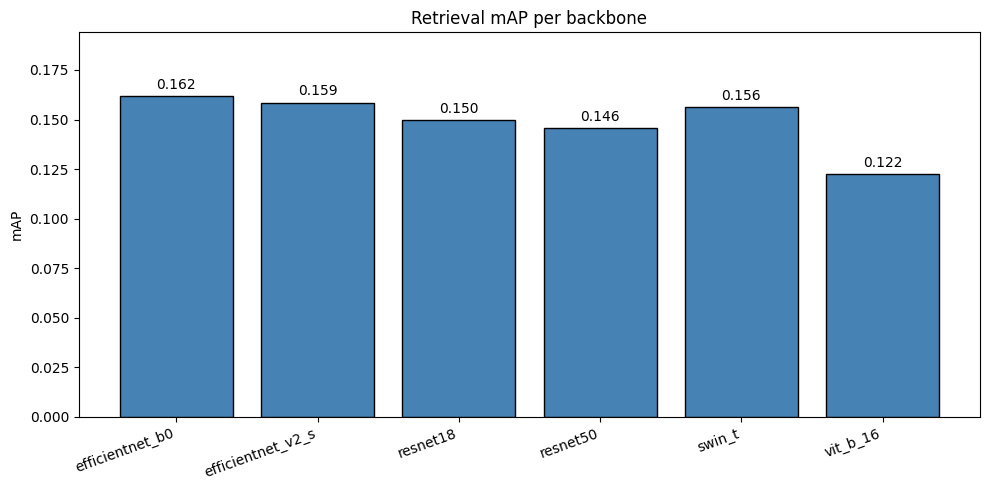

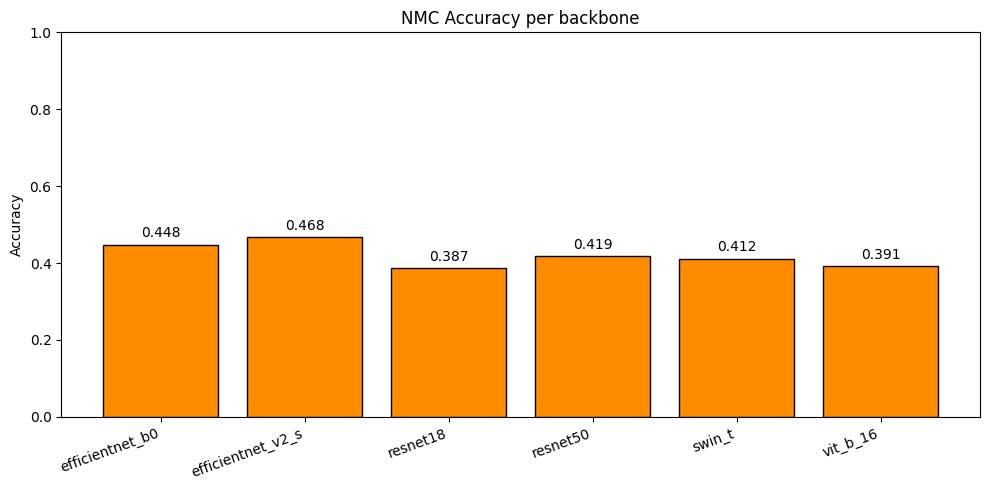

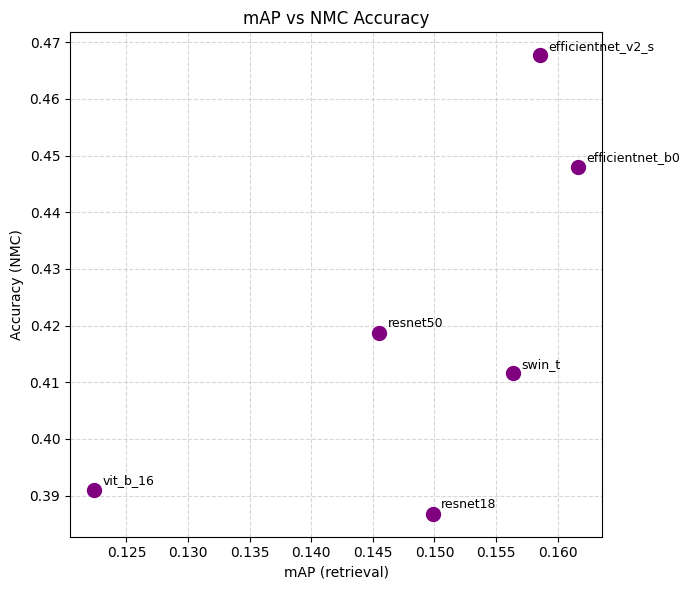

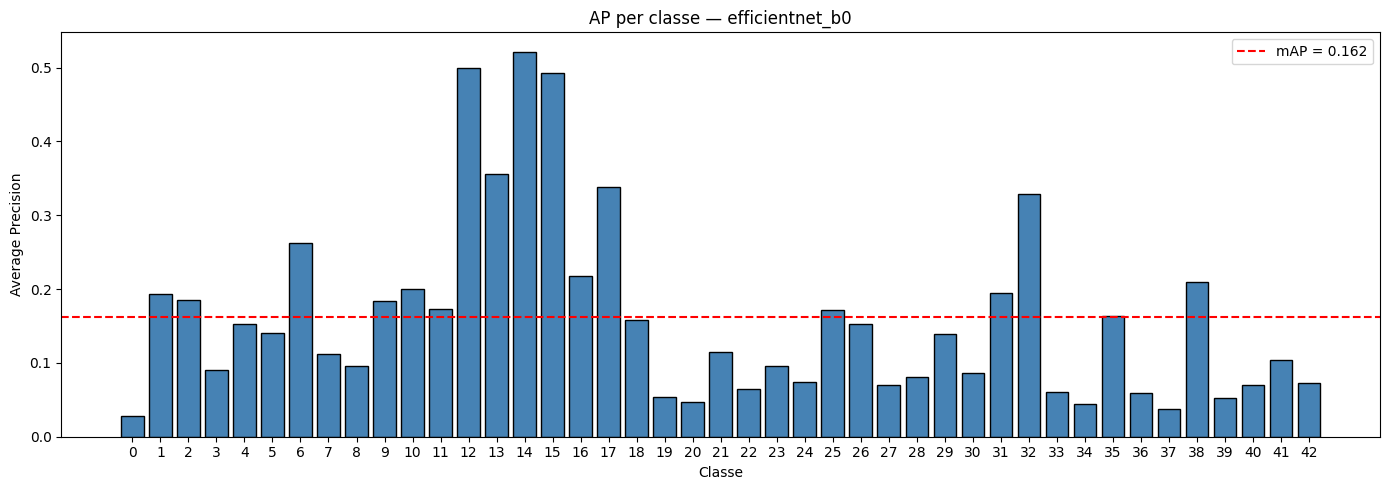

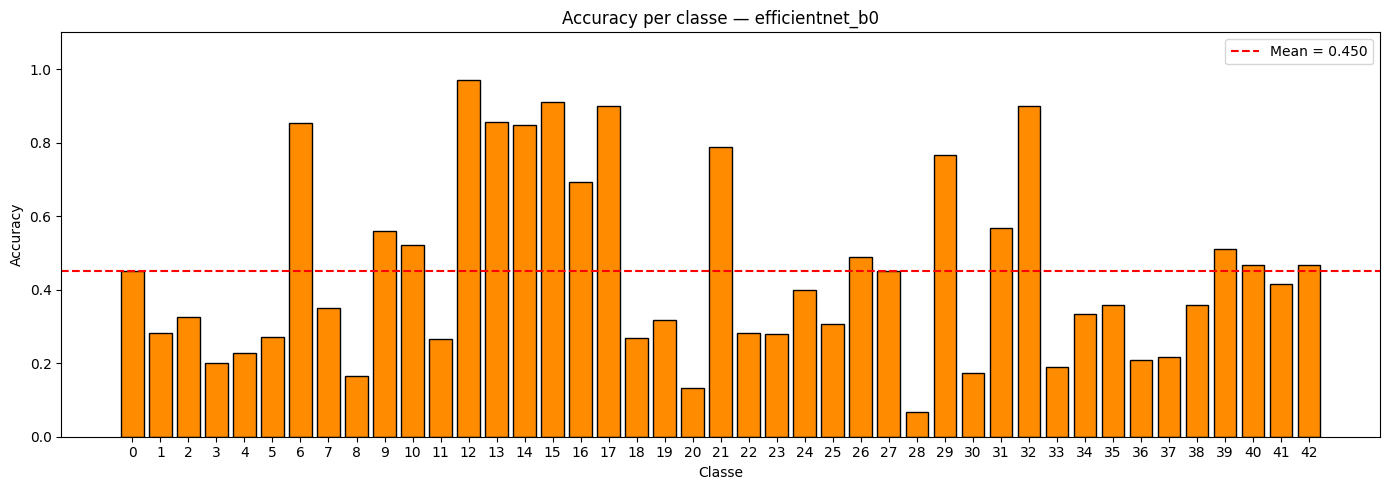

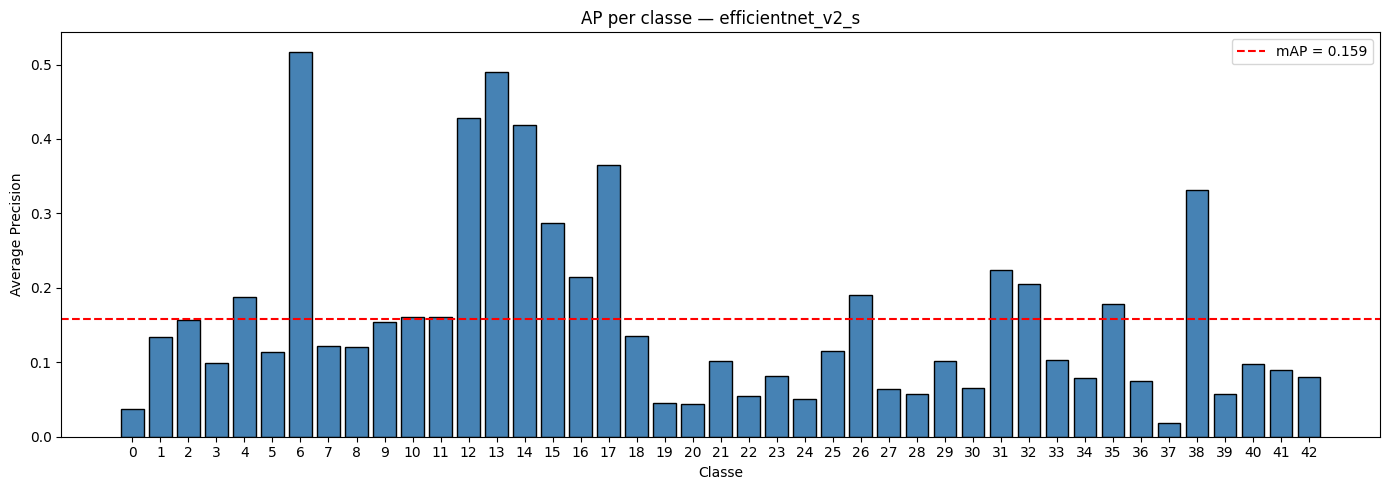

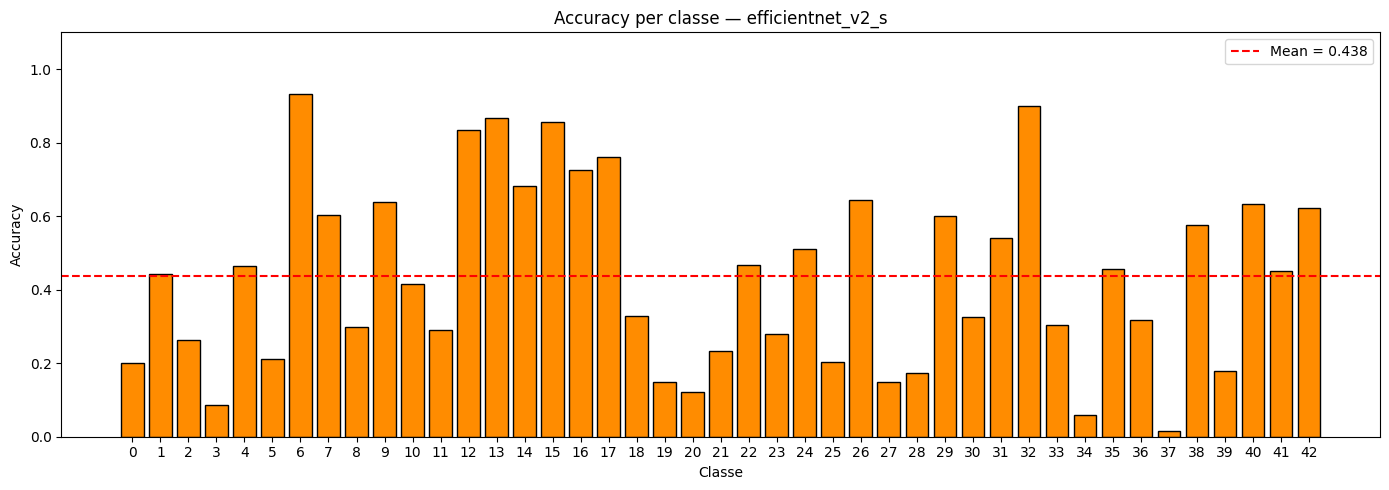

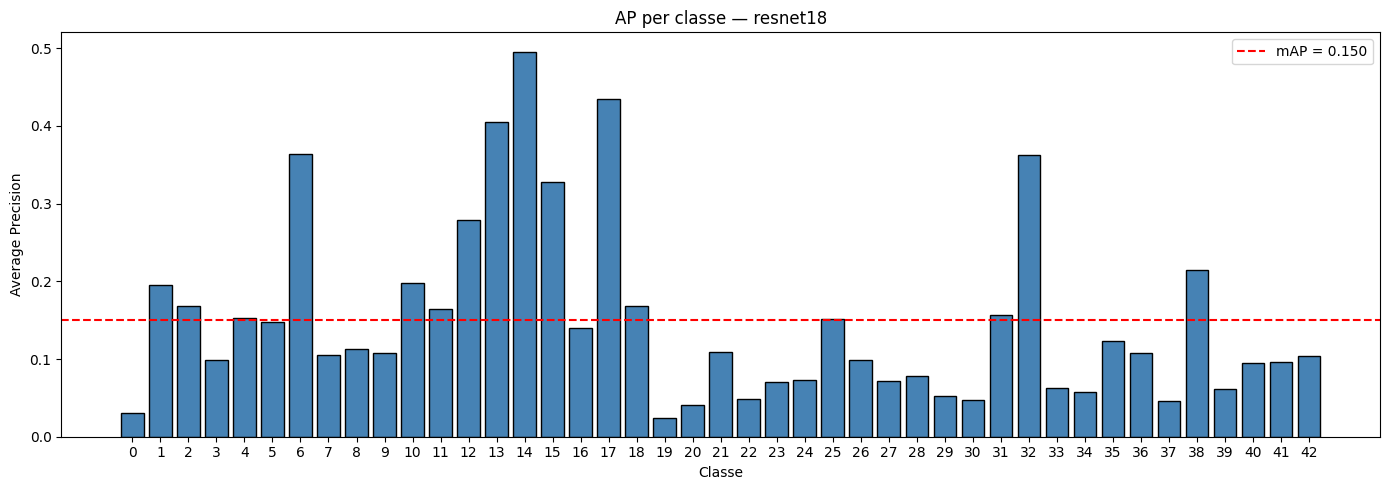

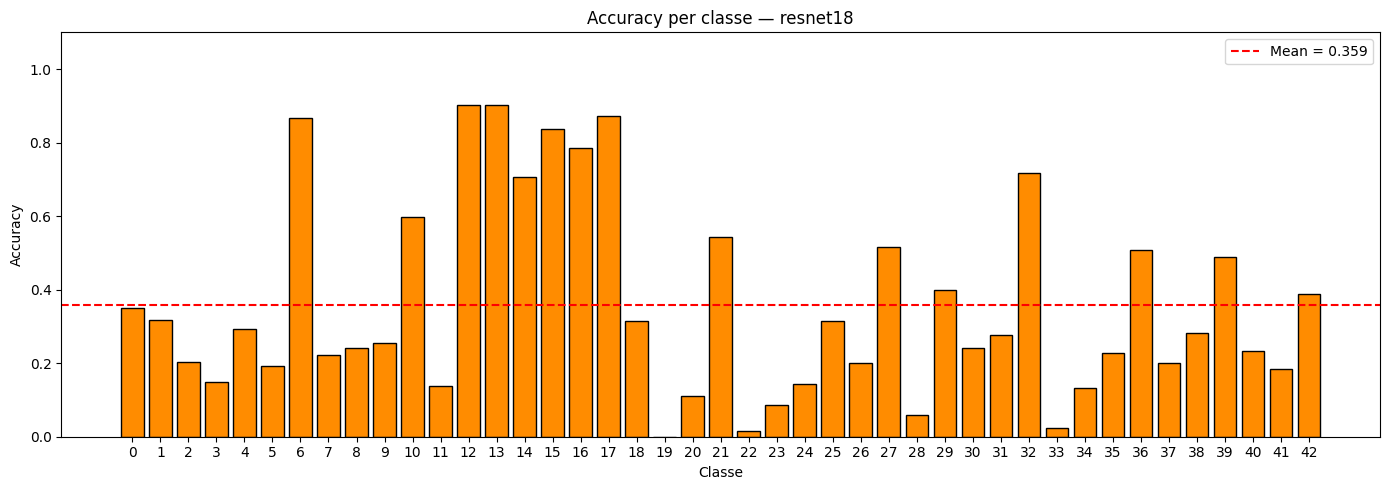

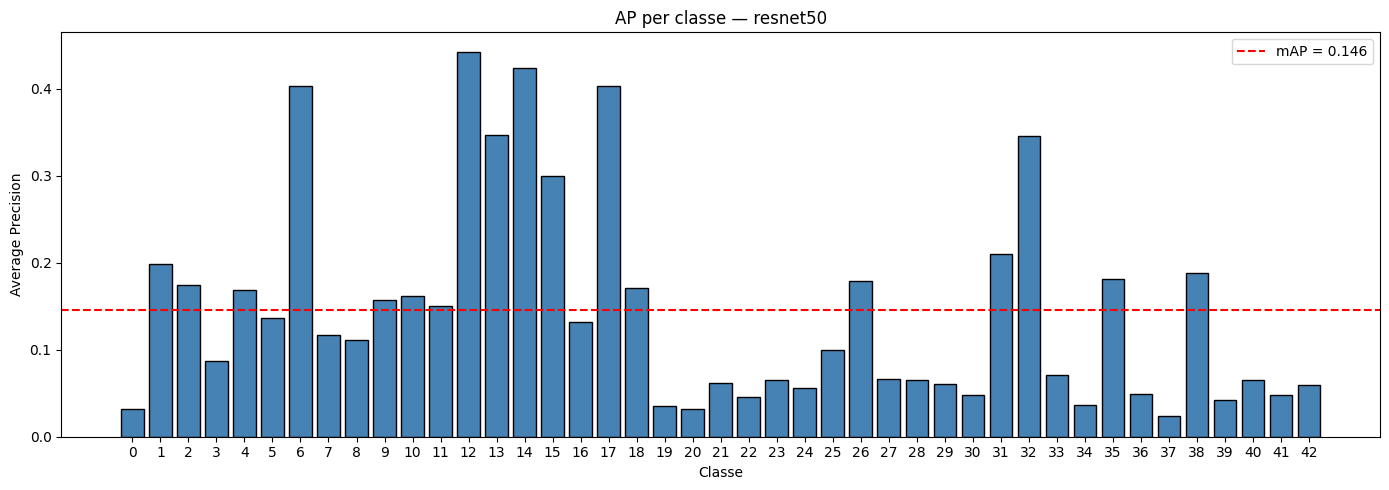

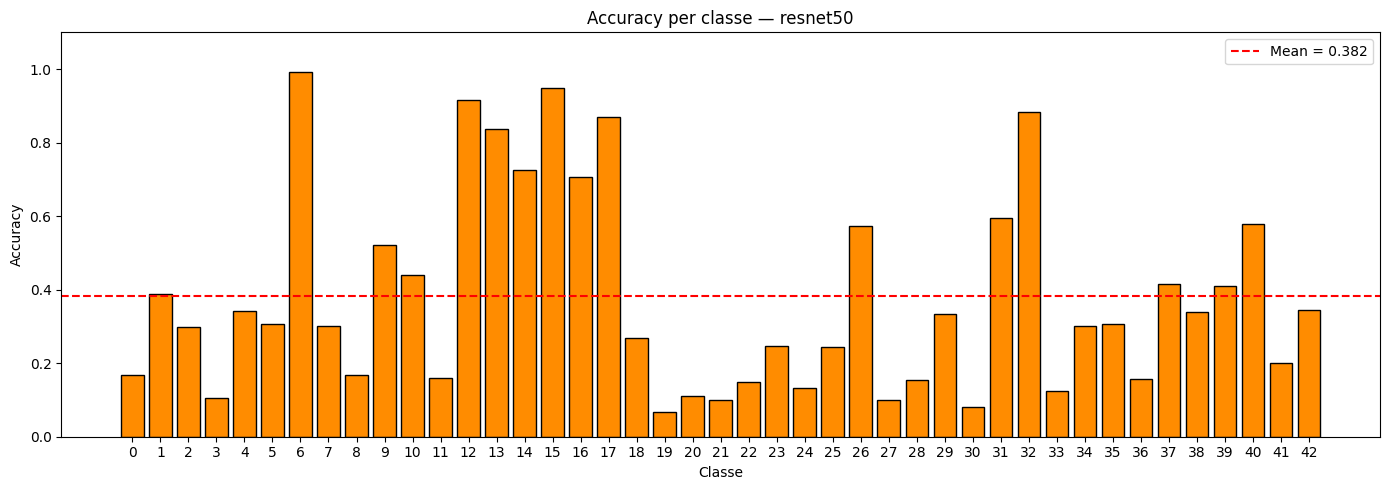

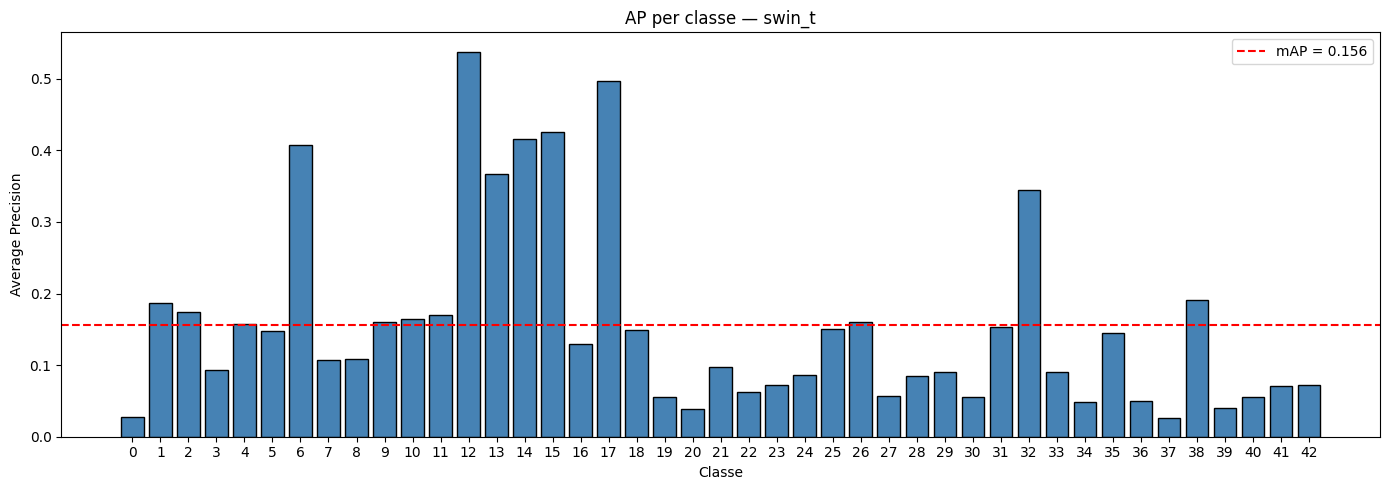

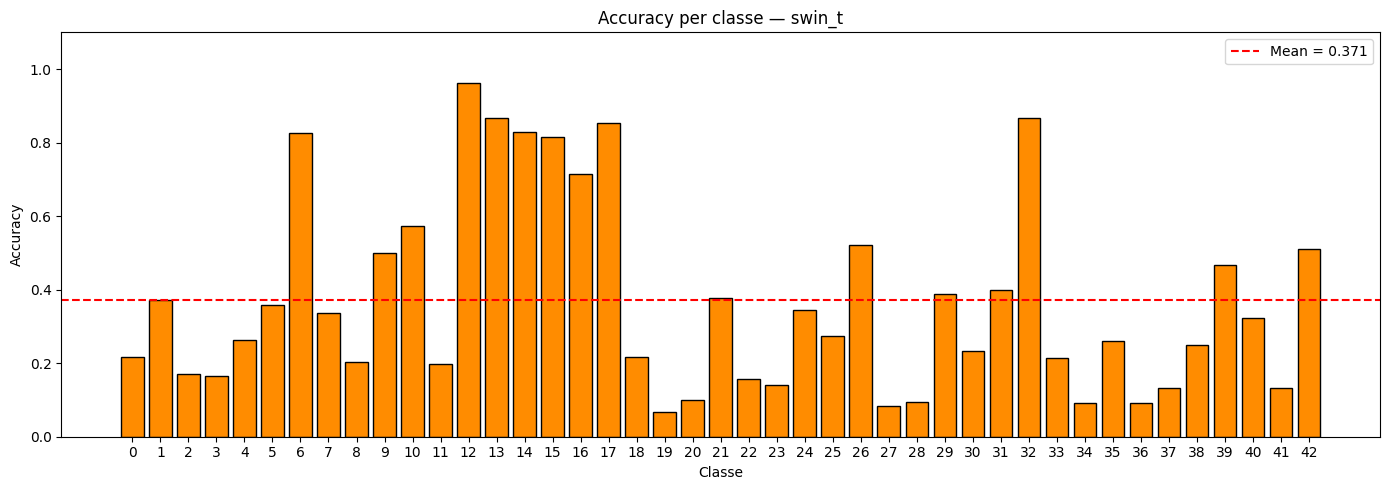

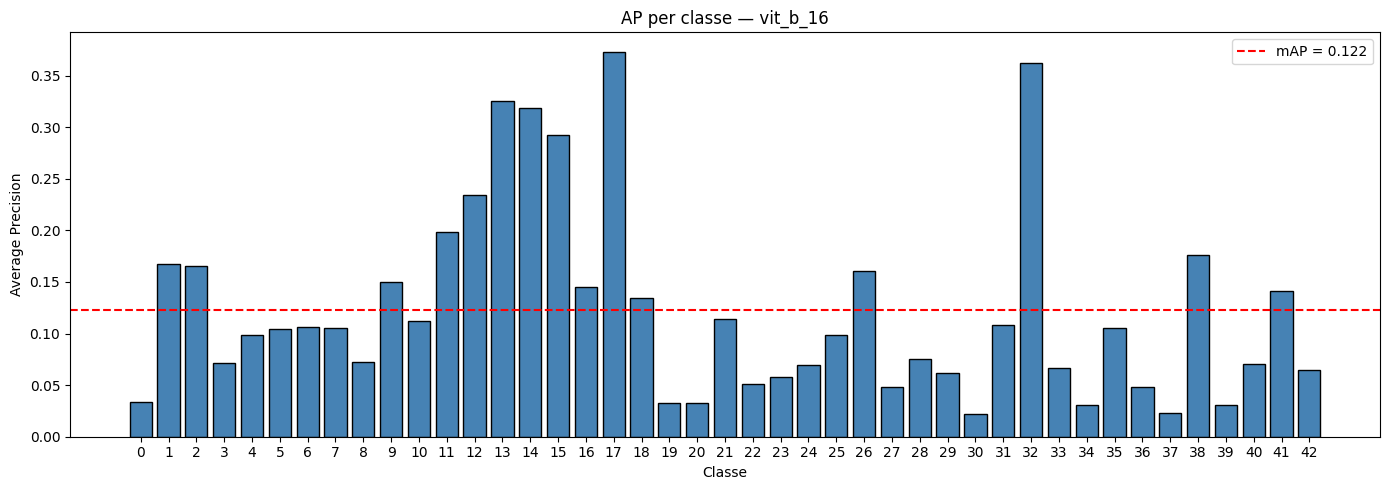

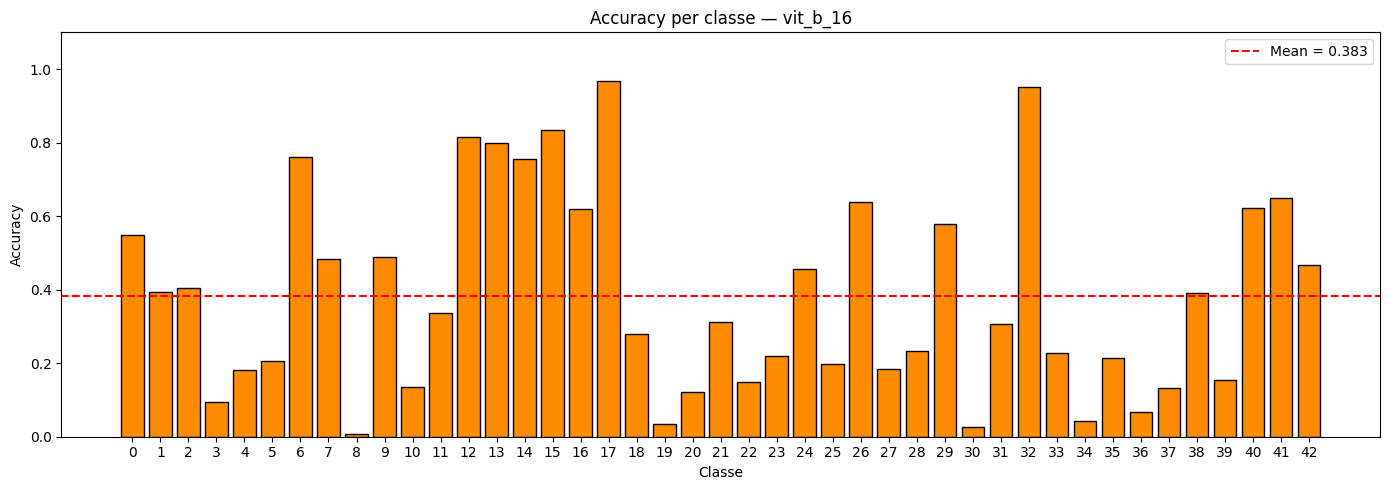

In [ ]:
from Rtfc.src.plot import plot_all
plot_all(results_dir=map_result_dir,classify_dir=classification_dir)

As we can see we obtain disappointing results as the most two 'promising' (least worse) results are:
- **efficientnet_v2_s**  
    - **mAP = 0.159 , acc = 0.468**  
    
     
- **efficientnet_b0**  
    - **mAP = 0.162 , acc = 0.448**  


After considerations I noticed that these two nets are **pretrained on 224 x 224 images**(but still accepting lower resolution images) so I will rerun the pipeline applying a transform that upscale the images and hope for the best.

In [4]:
config_path = "Rtfc/config/efficient_nets.yaml"
eff_config = load_yaml(config_path)
eff_config

{'efficientnet_b0': 'eff', 'efficientnet_v2_s': 'eff'}

In [5]:
map_result_dir = ".eff_map_results/"
classification_dir = ".eff_classification_results/"
features_path =".eff_features/"

In [ ]:
retrieve_and_classify(features_path=features_path,map_result_path=map_result_dir,classification_dir=classification_dir, config_path=config_path)

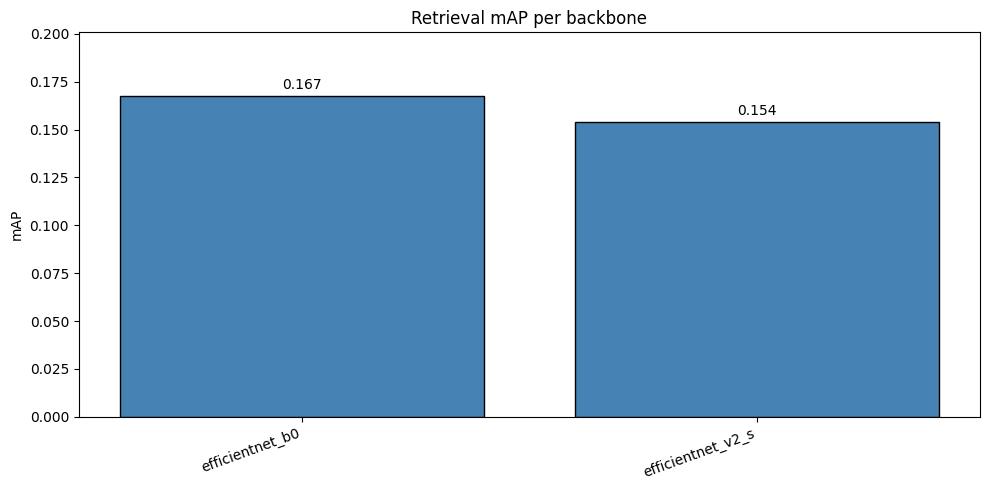

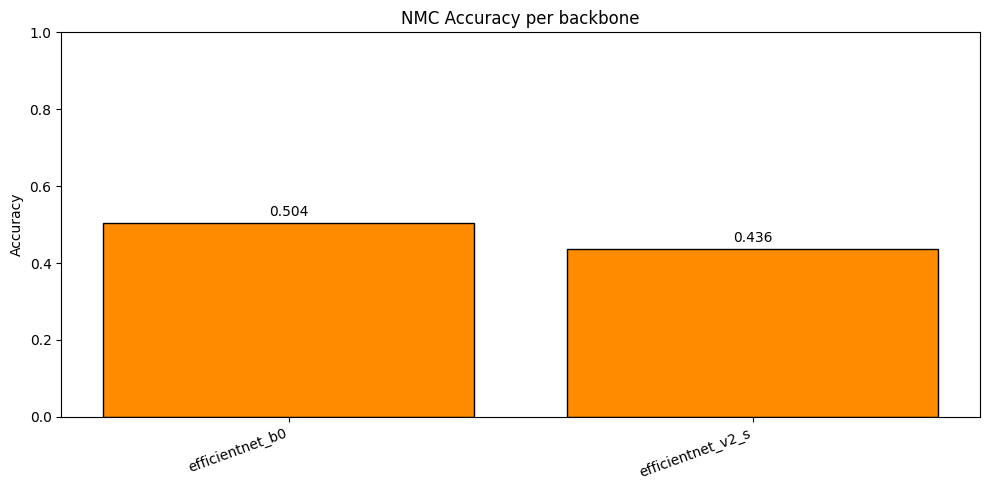

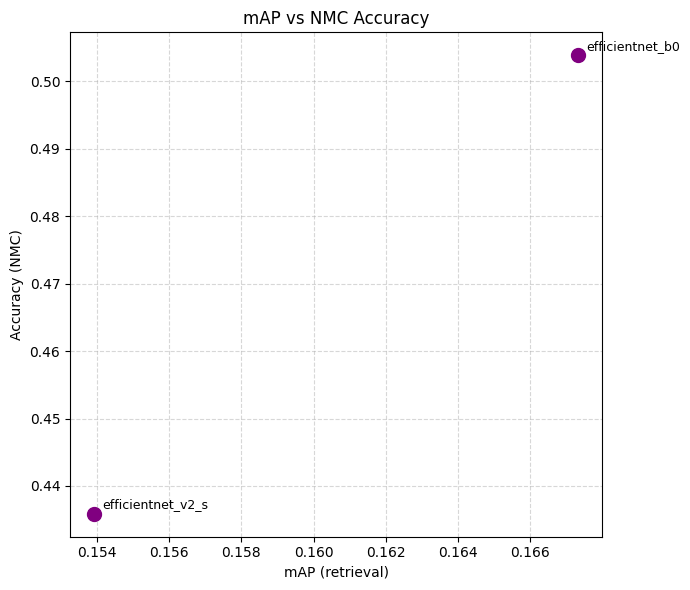

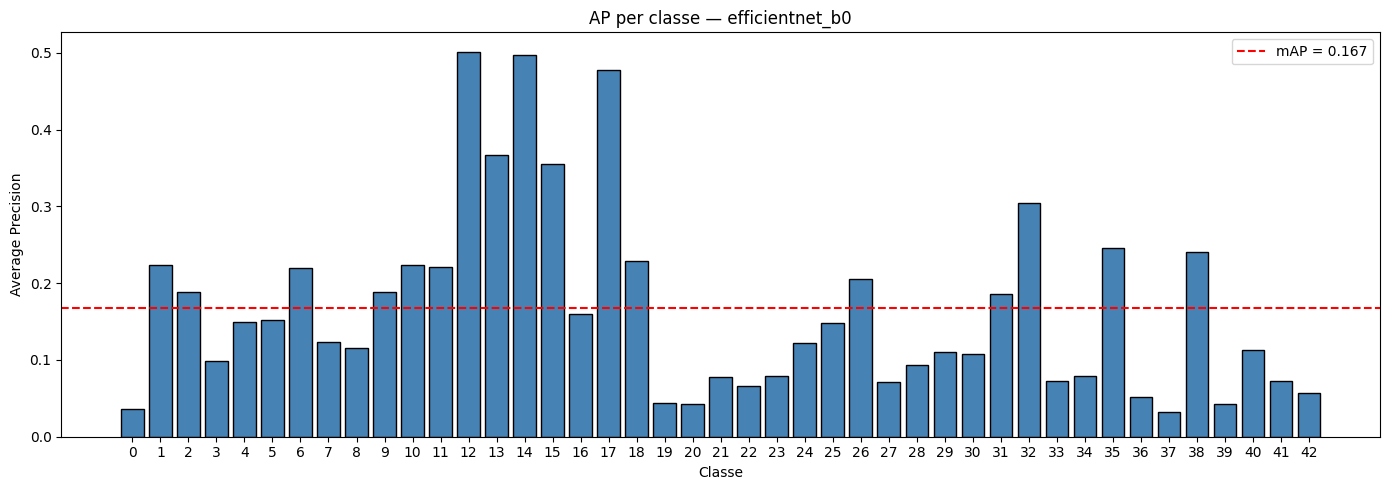

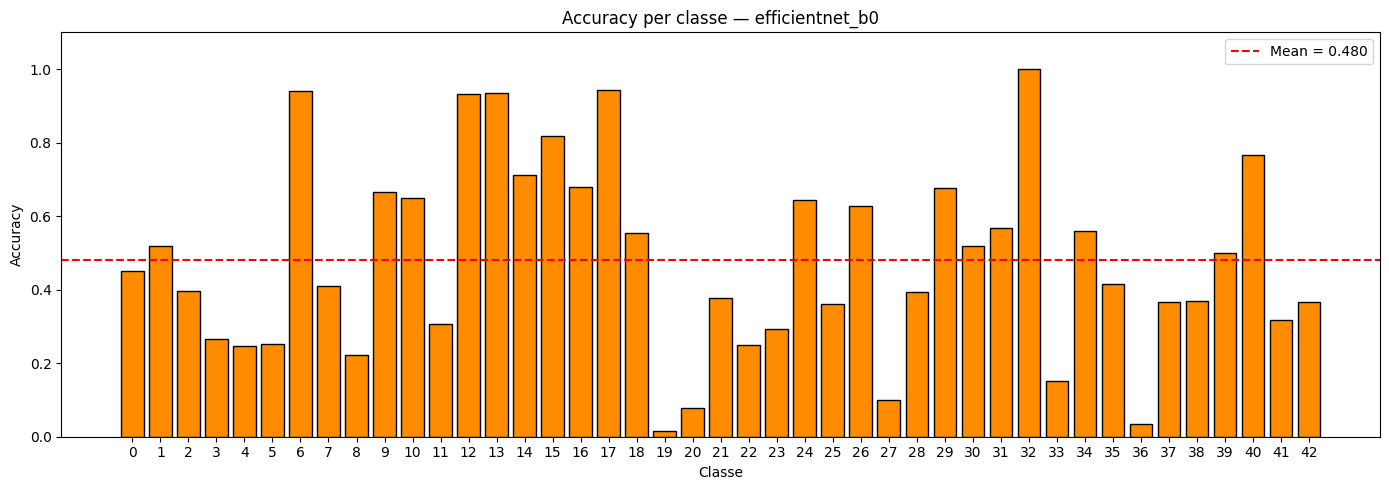

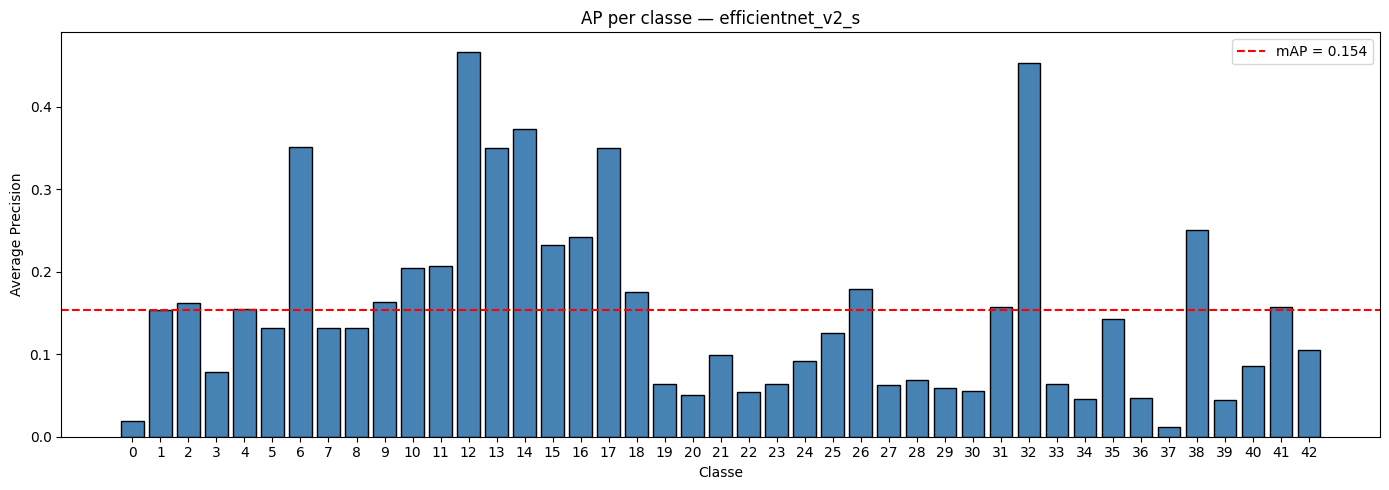

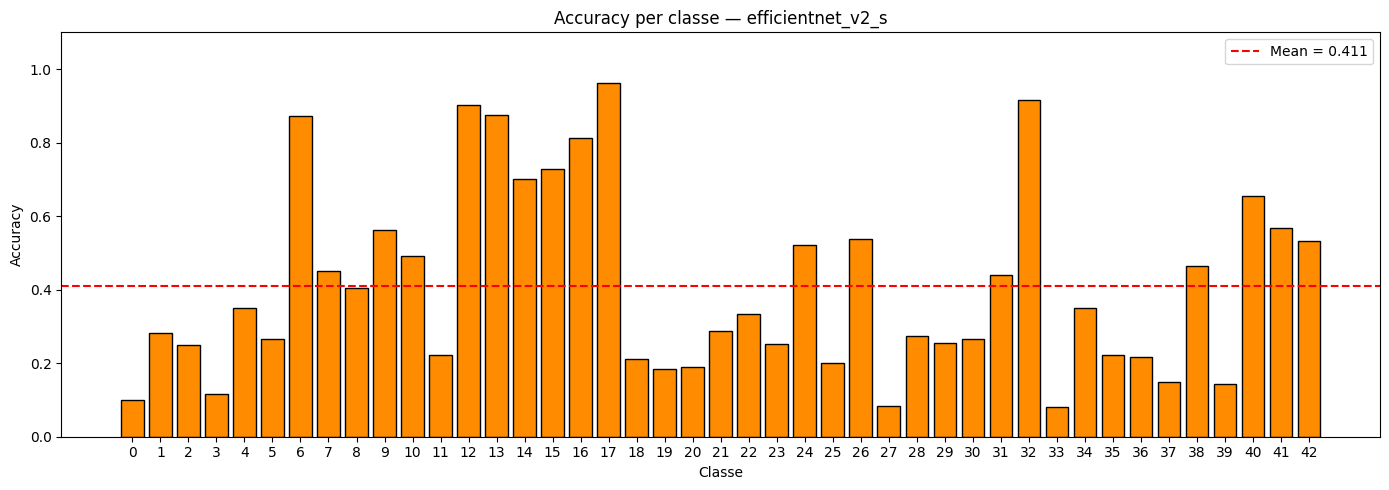

In [ ]:
plot_all(results_dir=map_result_dir,classify_dir=classification_dir)

Unfortunetly the **results didn't improve at all**.


---

### References
https://scikit-learn.org/stable/modules/svm.html (svm)  
https://arxiv.org/pdf/1905.11946EfficientNet (efficientnet_b0)
### AI usage
Used to generate the plotting function and to identify a bug in the code where I  was appending the entire list of validation losses in itself instead of the single value.


